# Wine Quality Comparative Study

### Multi-Class Classification — Red vs White Wine

## Section 1 — Problem Statement + Data Description

### **Problem statement.** 

We are given two tabular datasets of lab-measured wine
properties (`winequality-red.csv` and `winequality-white.csv`). The goal is to
predict the `quality` score of a wine as a **multi-class classification**
problem (every unique quality value, e.g. 3, 4, 5, 6, 7, 8, is its own class —
this is *not* regression and *not* binary classification).

Using both datasets I have conducted a **comparative study**
that answers three questions:
1. **Red vs White:** which dataset is easier to predict, and why?
2. **Model vs Model:** does a simple linear model (Logistic Regression) or a
   non-linear ensemble model (Random Forest) work better on each dataset?
3. **Class-level difficulty:** which quality scores are hardest to predict?

### **Data Description**

**What one row represents:** one wine sample with 11 chemical/physical
measurements (fixed acidity, volatile acidity, citric acid, residual sugar,
chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol) and quality rating.

**Target column:** `quality` — an integer rating, every distinct value is treated
as a separate class.

*What to expect in this dataset*
- Class imbalance: some quality scores appear much more frequently than others. 
- Overlapping classes: quality levels like 5 and 6 may have similar feature values, 
making them harder to separate.

## Task 1 - Task 1 — Load & Inspect the Data (Red + White) 

Instructions:
1. Load both CSV files using sep=";". 
2. Print for each dataset: 
- shape (rows, cols) 
- first 5 rows 
- column list 
3. Verify the target column quality exists. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)


In [2]:
#loading both datasets
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

print("RED wine shape:", red.shape)
print("WHITE wine shape:", white.shape)

RED wine shape: (1599, 12)
WHITE wine shape: (4898, 12)


In [3]:
print("RED — first 5 rows:")
red.head()

RED — first 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
print("WHITE — first 5 rows:")
white.head()

WHITE — first 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
print("RED columns:", list(red.columns))
print()
print("WHITE columns:", list(white.columns))
print()

RED columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

WHITE columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']



- Both the datasets are loaded correctly and have 11 numeric feature columns 
- number of features RED- 1599 and WHITE - 4898.

## Task 2 - Data Quality Checks + Class Distribution (Comparative)

*Instructions (do for red and white separately)*
1. Check missing values per column. 
2. Check duplicates. 
3. Show quality class distribution: 
○ counts 
○ percentages 
4. Plot a bar chart of quality counts.

### Task 2.1

In [6]:
print("Missing values per column — RED:")
print(red.isnull().sum())
print()
print("Missing values per column — WHITE:")
print(white.isnull().sum())

Missing values per column — RED:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Missing values per column — WHITE:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### TAsk 2.2- Check Duplicates

In [7]:
red_dupes = red.duplicated().sum()
white_dupes = white.duplicated().sum()
print("Duplicate rows:")
print(f"RED- {red_dupes}")
print(f"WHITE- {white_dupes}")


Duplicate rows:
RED- 240
WHITE- 937


### Task 2.3 - Quality class distribution for each dataset

In [8]:
#RED
red_counts = red['quality'].value_counts().sort_index()
red_pct = (red['quality'].value_counts(normalize=True).sort_index() * 100).round(2)
print("RED quality distribution (counts):")
print(red_counts)
print("\nRED quality distribution (%):")
print(red_pct)

RED quality distribution (counts):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

RED quality distribution (%):
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


In [26]:
#WHITE
white_counts = white['quality'].value_counts().sort_index()
white_pct = (white['quality'].value_counts(normalize=True).sort_index() * 100).round(2)
print("WHITE quality distribution (counts):")
print(white_counts)
print("\nWHITE quality distribution (%):")
print(white_pct)

WHITE quality distribution (counts):
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

WHITE quality distribution (%):
quality
3     0.41
4     3.33
5    29.75
6    44.88
7    17.97
8     3.57
9     0.10
Name: proportion, dtype: float64


### Task 2.4 Bar chart of quality counts

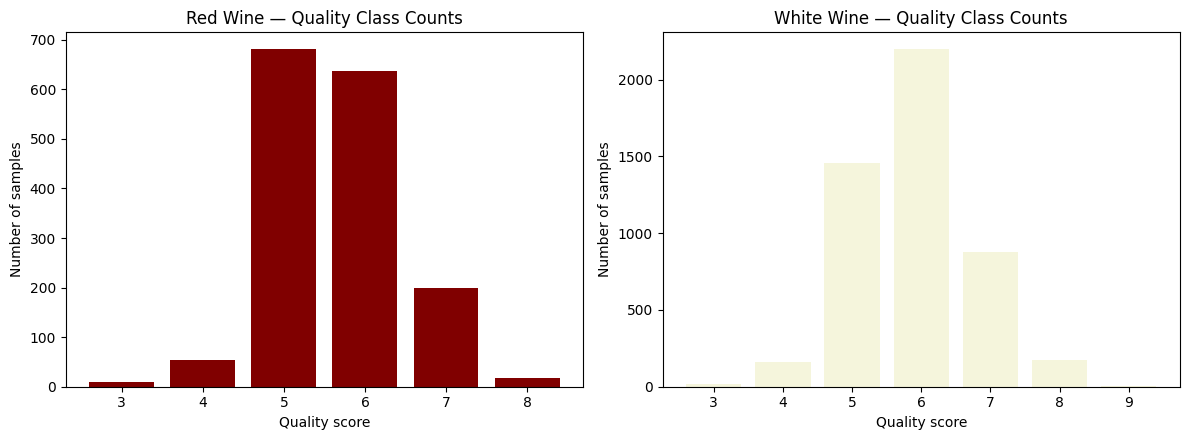

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(red_counts.index.astype(str), red_counts.values, color="Maroon")
axes[0].set_title("Red Wine — Quality Class Counts")
axes[0].set_xlabel("Quality score")
axes[0].set_ylabel("Number of samples")

axes[1].bar(white_counts.index.astype(str), white_counts.values, color="Beige")
axes[1].set_title("White Wine — Quality Class Counts")
axes[1].set_xlabel("Quality score")
axes[1].set_ylabel("Number of samples")

plt.tight_layout()
plt.show()

### Comparative Questions:

- **Which dataset is more imbalanced?**
From the analysis done so far, both seem to have imblanace. The *RED* one is more imbalanced than WHITE as majority of the quality score lies at 5,6. In the case of WHite wine data the quality score is majorly distributed at 5,6,7 but there is hardly any samples at the extremes such as quality score 9.

- **Which Quality classes are rare?** 
In RED wine dataset quality 3 and 8 are rare and in case of White wine dataset the quality 3, 4, 8 and 9 are rare.

- **Why are rare classes harder to predict?** The difficulty to predict is due to low number of samples. The model cannot learn well and hence later cannot generalise well. 


## Task 3 -  Prepare Data for Modeling (Same Setup for Fair Comparison)

Instructions (do for both datasets) 
1. Create: 
- X = all columns except quality 
- y = quality 
2. Train-test split with: 
- test_size=0.2 
- random_state=42 
- stratify=y 

In [29]:
#  RED 
X_red = red.drop(columns=['quality'])
y_red = red['quality']
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)

# WHITE 
X_white = white.drop(columns=['quality'])
y_white = white['quality']
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)

print("RED   -> X_train:", X_red_train.shape, " X_test:", X_red_test.shape)
print("WHITE -> X_train:", X_white_train.shape, " X_test:", X_white_test.shape)

RED   -> X_train: (1279, 11)  X_test: (320, 11)
WHITE -> X_train: (3918, 11)  X_test: (980, 11)


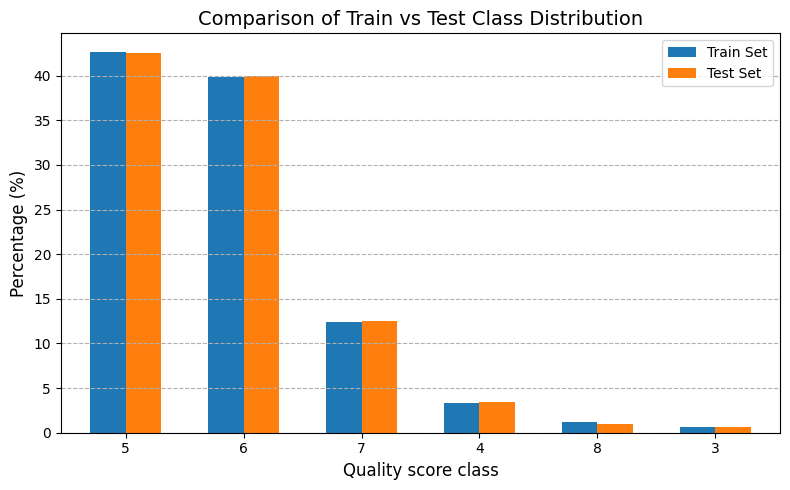

RED y train quality
3     0.63
4     3.28
5    42.61
6    39.87
7    12.43
8     1.17
Name: proportion, dtype: float64

RED test class %: quality
3     0.62
4     3.44
5    42.50
6    40.00
7    12.50
8     0.94
Name: proportion, dtype: float64


In [ ]:
# Convert to Series and calculate percentages
train_pct = pd.Series(y_red_train).value_counts(normalize=True) * 100
test_pct = pd.Series(y_red_test).value_counts(normalize=True) * 100

df_plot = pd.DataFrame({
    'Train Set': train_pct,
    'Test Set': test_pct
})

#bar chart
ax = df_plot.plot(kind='bar', figsize=(8, 5), width=0.6, color=['blue', 'orange'])
plt.title('Comparison of Train vs Test Class Distribution', fontsize=14)
plt.xlabel('Quality score class', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

pct_y_train = (y_red_train.value_counts(normalize=True).sort_index()*100).round(2)
pct_y_test = (y_red_test.value_counts(normalize=True).sort_index()*100).round(2)

print("RED y train", pct_y_train)
print("\nRED test class %:", pct_y_test)

The plot and the percentages show the train vs trest distribution. It can be confirmed from both the plot and the percentages that each class share of the data is nearly identical between train and test. This confirms that stratify=y preserved the original class balance in the split.

## Task 4 - Model A (Baseline): Logistic Regression (Red vs White)

*Instructions*

Train Model A on both datasets using a Pipeline: 
- StandardScaler() 
- LogisticRegression(max_iter=5000) 

In [92]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, labels):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    print(f"------ {name} ------")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro F1-score : {f1_macro:.4f}")
    print()
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {"model": model, "accuracy": acc, "f1_macro": f1_macro, "y_pred": y_pred}

------ RED — Logistic Regression ------
Accuracy       : 0.5906
Macro F1-score : 0.2776

Classification report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



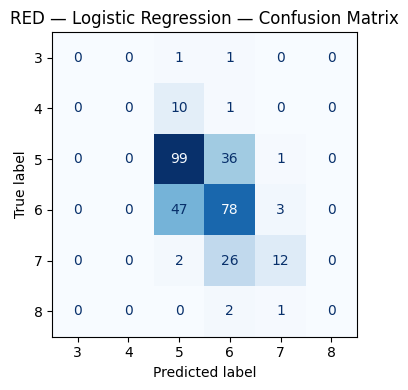

In [ ]:
red_labels = sorted(y_red.unique())
white_labels = sorted(y_white.unique())

pipe_lr_red = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])
res_lr_red = evaluate_model("RED — Logistic Regression", pipe_lr_red, X_red_train, y_red_train, X_red_test, y_red_test, red_labels)

------ WHITE — Logistic Regression ------
Accuracy       : 0.5490
Macro F1-score : 0.2367

Classification report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



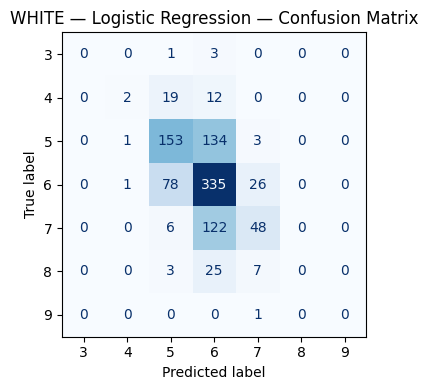

In [94]:
pipe_lr_white = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])
res_lr_white = evaluate_model("WHITE — Logistic Regression", pipe_lr_white,
                               X_white_train, y_white_train, X_white_test, y_white_test, white_labels)

- **Which dataset performed better for Logistic Regression?** 

RED performed better for logistic regression. This is determined by higher accuracy amd macro F1 (59.1% and 0.278) values as compared to those of WHITE(54.9% and 0.237).



- **Which quality class looks hardest (lowest recall)?** 

For both datasets, the extreme classes have **0.00 recall**. RED's classes 3, 4 and 8 and WHITE's classes 3, 8 and 9 are never predicted correctly by Logistic Regression. This is because of the low number of training examples for those classes

## Task 5-  Task 5 — Model B (Tree Model): Random Forest (Red vs White) 

*Instructions*

Train Model B on both datasets: 
- RandomForestClassifier(n_estimators=300, random_state=42) 

Evaluate using the same metrics as Task 4:
  Accuracy, Confusion Matrix, Classification Report and Macro F1-score 


------ RED — Random Forest ------
Accuracy       : 0.6813
Macro F1-score : 0.4094

Classification report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



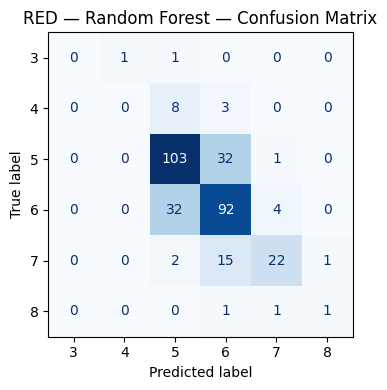

In [95]:
#Random forest fro RED
rf_red = RandomForestClassifier(n_estimators=300, random_state=42)
res_rf_red = evaluate_model("RED — Random Forest", rf_red,
                             X_red_train, y_red_train, X_red_test, y_red_test, red_labels)

------ WHITE — Random Forest ------
Accuracy       : 0.6724
Macro F1-score : 0.4222

Classification report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



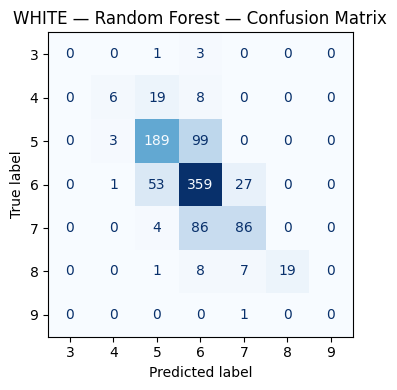

In [ ]:
rf_white = RandomForestClassifier(n_estimators=300, random_state=42)
res_rf_white = evaluate_model("WHITE — Random Forest", rf_white, X_white_train, y_white_train, X_white_test, y_white_test, white_labels)

- **Did Random Forest improve Compared to Logistic Regression?** 

Yes, Random forest imporved the results as compared to logistic regression on both datasets. 

RED improved from 59.1%  to **68.1%** accuracy and 0.278 to **0.409** macro
F1. WHITE improved from 54.9% to **67.2%** accuracy and 0.237 to **0.422** macro F1.The improvement is higher for WHITE. 

This suggests that it was more difficult for linear regressor to capture the dataset and that the tree emsemble handles that non-linearity much better.


- **Which class is still hardest?** 

In my opinione the extreme classes (RED: 3 WHITE- 3,9) still remain the hardest to capture even for Random Forest. Still geeting the 0.00 recall/precision for almost every quality score.



## Task 6 - Task 6 — Comparative Metrics Summary (Core Comparative Study Output) 

*Instructions*


Create a clean summary for all four experiments using only: 
- Accuracy 
- Confusion Matrix 
- Classification Report 
- F1-score

Include: Confusion Matrix and Classification Report

In [87]:
summary_rows = [
    ("Red",   "Logistic Regression", res_lr_red["accuracy"],   res_lr_red["f1_macro"]),
    ("Red",   "Random Forest",       res_rf_red["accuracy"],   res_rf_red["f1_macro"]),
    ("White", "Logistic Regression", res_lr_white["accuracy"], res_lr_white["f1_macro"]),
    ("White", "Random Forest",       res_rf_white["accuracy"], res_rf_white["f1_macro"]),
]

summary_df = pd.DataFrame(summary_rows, columns=["Dataset", "Model", "Accuracy", "F1-score (macro)"])
summary_df["Accuracy"] = summary_df["Accuracy"].round(4)
summary_df["F1-score (macro)"] = summary_df["F1-score (macro)"].round(4)
summary_df["Key Observation"] = [
    "Best linear-model dataset but weak on rare classes 3/4/8",
    "Best overall result",
    "Weakest result",
    "Biggest improvement",
]
summary_df

,Dataset,Model,Accuracy,F1-score (macro),Key Observation
0,Red,Logistic Regression,0.5906,0.2776,Best linear-model dataset but weak on rare cla...
1,Red,Random Forest,0.6812,0.4094,Best overall result
2,White,Logistic Regression,0.5490,0.2367,Weakest result
3,White,Random Forest,0.6724,0.4222,Biggest improvement


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Dataset</th>
      <th>Model</th>
      <th>Accuracy</th>
      <th>F1-score (macro)</th>
      <th>Key Observation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Red</td>
      <td>Logistic Regression</td>
      <td>0.5906</td>
      <td>0.2776</td>
      <td>Best linear-model dataset but weak on rare cla...</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Red</td>
      <td>Random Forest</td>
      <td>0.6812</td>
      <td>0.4094</td>
      <td>Best overall result</td>
    </tr>
    <tr>
      <th>2</th>
      <td>White</td>
      <td>Logistic Regression</td>
      <td>0.5490</td>
      <td>0.2367</td>
      <td>Weakest result</td>
    </tr>
    <tr>
      <th>3</th>
      <td>White</td>
      <td>Random Forest</td>
      <td>0.6724</td>
      <td>0.4222</td>
      <td>Biggest improvement</td>
    </tr>
  </tbody>
</table>
</div>

### Confusion Matrices:

*Logistic Regression*

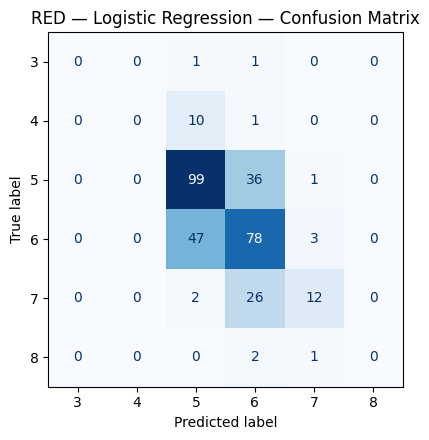
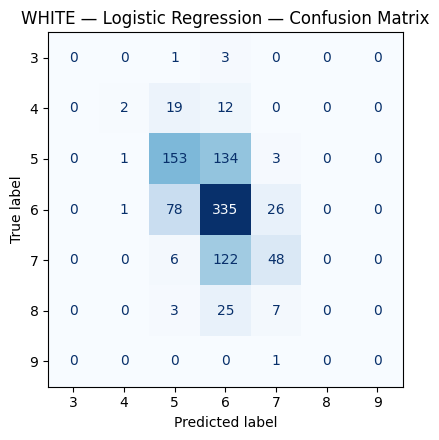


*Random Forest*

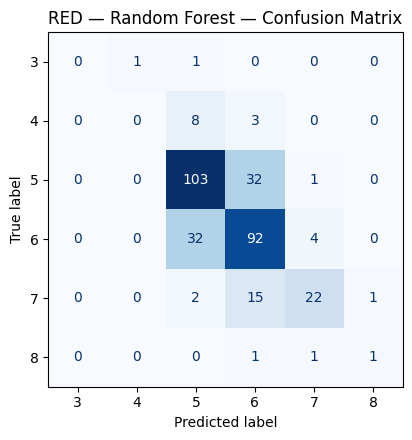
![alt text](image.png)



### Classification Reports:
#### Logistic Regresstion

------ RED — Logistic Regression ------

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
    macro avg       0.31      0.27      0.28       320
    weighted avg    0.57      0.59      0.57       320

------ WHITE — Logistic Regression ------


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
    macro avg       0.31      0.23      0.24       980
    weighted avg    0.53      0.55      0.52       980

#### Random Forest

------ RED — Random Forest ------

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
    macro avg       0.44      0.39      0.41       320
    weighted avg    0.66      0.68      0.67       320

------ WHITE — Random Forest ------

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
    macro avg       0.52      0.38      0.42       980
    weighted avg    0.68      0.67      0.66       980

### Summary:

- The best result is the Random Forest on RED wine dataset with an accuracy of 68.1%.
- The best model for both the dataset turned out to be Random forset with better results as compared to logistic regession. The main reason is that there is non-linearity in each datset and the Random Forest model is able to handle it better.
- WHile comparing both models RED has better results which could be due to the fact that red has more values in the centre and less in the extreme classes. This shows how important distribution as RED was more accurately predicted even though white has almost 3 times the number of rows as compared to red.


## Task 7- Final Conclusion (Comparative Summary) 

Across both the wines (datasets), Random Forest was consistently the stronger of the two models used in this study. Red Wine was easier to predict. This is infered from the fact that both models scored a few points higher on the Red wine data than on the White wine. The quality scores of Red were more in the dominant classes (5 and 6) and made up majority of the red dataset. This makes it easier fr the model to predict, whereas in white the data is more evenly distributed (majority in 5,6,7 and less emptier extreme classes). Further, Random Forest Model performed better on both datasets by a huge margin. This could be due to the features (physical/chemical) that might be having overlapping vlaues. This leads to non-linearity in the dataset which can be better handled by Random Forest than Logistic Regression model. The most confusing or difficult to predict were the classes on both the ends of distribution(3,4,8,9) which had very few qaultiy scores. The main reason for the difficult was very low training smaples in that space while the other classes had thousands of samples. This causes the model to not accurately recognise the patterns in these classes and  the prediction is done in majority class. 

As we discussed the issue with the distribution of data, I think one improvement to try next would be *class_weight = "balanced"*. This would target the exact problem discussed above which is the model under predicting the rare or extreme classes as the prediction is dominated by the majority classes. Additionally, the models wouldn't need to be trained again or need additional data. So this is a fast and easy way to check if this would help and improve the results. 